# Capstone Project: Crop Yield Prediction Using Machine Learning

## Data Understanding

### Introduction
- Data understanding is the first stage of the data science workflow and provides the foundation for data preprocessing, exploratory data analysis (EDA), and predictive modeling. The Crop Yield Prediction dataset downloaded from Kaggle consists of five CSV files: `rainfall.csv`, `temp.csv`, `pesticides.csv`, `yield.csv`, and `yield_df.csv`.
- Among these files, `yield_df.csv` is an integrated dataset that combines the key environmental and agricultural variables required for this study, including rainfall, average temperature, pesticide usage, crop type, geographical area, year, and crop yield. Therefore, `yield_df.csv` was selected as the primary dataset for analysis.
- This section focuses on understanding the structure and quality of the dataset by examining its dimensions, variables, data types, summary statistics, missing values, duplicate records, and overall suitability for subsequent preprocessing and predictive modeling.


In [1]:
# Import pandas library
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

pd.set_option("display.max_columns", None)

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
# Load the dataset
df = pd.read_csv("yield_df.csv")

In [3]:
# Display first five rows
df.head()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


The head() function displays the first five rows of the dataset, allowing us to preview its structure and contents.

In [4]:
# Display last five rows
df.tail()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
28237,28237,Zimbabwe,"Rice, paddy",2013,22581,657.0,2550.07,19.76
28238,28238,Zimbabwe,Sorghum,2013,3066,657.0,2550.07,19.76
28239,28239,Zimbabwe,Soybeans,2013,13142,657.0,2550.07,19.76
28240,28240,Zimbabwe,Sweet potatoes,2013,22222,657.0,2550.07,19.76
28241,28241,Zimbabwe,Wheat,2013,22888,657.0,2550.07,19.76


The tail() function displays the last five rows of the dataset to ensure that all records have been loaded correctly.

In [5]:
# Check the number of rows and columns
df.shape

(28242, 8)

The shape attribute returns the number of rows and columns in the dataset.

In [6]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     28242 non-null  int64  
 1   Area                           28242 non-null  object 
 2   Item                           28242 non-null  object 
 3   Year                           28242 non-null  int64  
 4   hg/ha_yield                    28242 non-null  int64  
 5   average_rain_fall_mm_per_year  28242 non-null  float64
 6   pesticides_tonnes              28242 non-null  float64
 7   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(3), object(2)
memory usage: 1.7+ MB


The info() function provides information about the dataset, including the number of entries, column names, data types, and non-null values.

In [7]:
# Summary statistics
df.describe()

,Unnamed: 0,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,28242.000000,28242.000000,28242.000000,28242.00000,28242.000000,28242.000000
mean,14120.500000,2001.544296,77053.332094,1149.05598,37076.909344,20.542627
std,8152.907488,7.051905,84956.612897,709.81215,59958.784665,6.312051
min,0.000000,1990.000000,50.000000,51.00000,0.040000,1.300000
25%,7060.250000,1995.000000,19919.250000,593.00000,1702.000000,16.702500
50%,14120.500000,2001.000000,38295.000000,1083.00000,17529.440000,21.510000
75%,21180.750000,2008.000000,104676.750000,1668.00000,48687.880000,26.000000
max,28241.000000,2013.000000,501412.000000,3240.00000,367778.000000,30.650000


The describe() function generates descriptive statistics for all numerical variables, including the count, mean, standard deviation, minimum, maximum, and quartiles.

In [8]:
#This describes "Area", "Item", which are categorical variables.

df.describe(include="object")

,Area,Item
count,28242,28242
unique,101,10
top,India,Potatoes
freq,4048,4276


In [9]:
# Display data types
df.dtypes

Unnamed: 0                         int64
Area                              object
Item                              object
Year                               int64
hg/ha_yield                        int64
average_rain_fall_mm_per_year    float64
pesticides_tonnes                float64
avg_temp                         float64
dtype: object

This shows the data type of each variable in the dataset.

In [10]:
# Check missing values
df.isnull().sum()

Unnamed: 0                       0
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64

This checks whether any values are missing in each column.

In [11]:
# Check duplicate records
df.duplicated().sum()

0

This checks whether duplicate rows exist in the dataset.

| Variable                          | Description                                                      |
| --------------------------------- | ---------------------------------------------------------------- |
| **Unnamed: 0**                    | Index column automatically generated when the dataset was saved. |
| **Area**                          | Country or region where the crop was produced.                   |
| **Item**                          | Crop type.                                                       |
| **Year**                          | Year the data was collected.                                     |
| **hg/ha_yield**                   | Crop yield measured in hectograms per hectare.                   |
| **average_rain_fall_mm_per_year** | Average annual rainfall in millimetres.                          |
| **pesticides_tonnes**             | Quantity of pesticides used in tonnes.                           |
| **avg_temp**                      | Average annual temperature in degrees Celsius.                   |


### Target Variable
The target variable for this study is:
- **hg/ha_yield**

### Predictor Variables
The predictor variables include:
- Area
- Item
- Year
- average_rain_fall_mm_per_year
- pesticides_tonnes
- avg_temp

In [12]:
# Remove the unnecessary index column
df.drop("Unnamed: 0", axis=1, inplace=True)

In [13]:
#Checking again if their are duplicate after removing the unncessary index column (Unnamed: 0)

df.duplicated().sum()

2310

In [14]:
#Number of countries

print("Number of Countries:",df["Area"].nunique())

Number of Countries: 101


In [15]:
#Number of Crops

print("Number of Crop Types:",df["Item"].nunique())

Number of Crop Types: 10


In [16]:
#Crop types

df["Item"].value_counts()

Item
Potatoes                4276
Maize                   4121
Wheat                   3857
Rice, paddy             3388
Soybeans                3223
Sorghum                 3039
Sweet potatoes          2890
Cassava                 2045
Yams                     847
Plantains and others     556
Name: count, dtype: int64

In [17]:
#Year range

print("Earliest Year:",df["Year"].min())
print("Latest Year:",df["Year"].max())

Earliest Year: 1990
Latest Year: 2013


In [18]:
df.head()

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [19]:
df.columns

Index(['Area', 'Item', 'Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year',
       'pesticides_tonnes', 'avg_temp'],
      dtype='object')

The Unnamed: 0 column is an automatically generated index column and does not provide useful information for analysis, so it is removed.

### Summary of Findings

The dataset was successfully loaded into Jupyter Notebook and examined.

Key findings include:

- The dataset contains **28,242 rows** and **8 columns**.
- It contains both categorical ('Area' and 'Item') and numerical variables ('Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', and 'avg_temp').
- After removing the unnecessary index column ('Unnamed:0'), seven meaningful variables remained.
- After removing the unnecessary index column (Unnamed:0), a second duplicate check identified 2310 duplicate records. This indicates that the unique-index column initially masked duplicate observations.
- The duplicates will be examined and appropriately handled during the data cleaning and preprocessing stage.
- There are **no missing values** in the dataset.

### Handling Duplicates

In [20]:
#This shows the number of rows and columns

print(df.shape)


#To show the number of duplicates in the data set
print(df.duplicated().sum())

(28242, 7)
2310


In [21]:
#identification of duplicates

duplicates = df[df.duplicated(keep=False)]

duplicates.head()

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
2082,Bangladesh,Maize,1990,10015,2666.0,1266.0,25.98
2083,Bangladesh,Maize,1990,10015,2666.0,1266.0,25.98
2084,Bangladesh,Potatoes,1990,91410,2666.0,1266.0,25.98
2085,Bangladesh,Potatoes,1990,91410,2666.0,1266.0,25.98
2086,Bangladesh,"Rice, paddy",1990,25661,2666.0,1266.0,25.98


In [22]:
df.head()

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [23]:
# Remove duplicate records and store the cleaned dataset
df_clean = df.drop_duplicates()

In [24]:
print(df.shape)
print(df_clean.shape)

(28242, 7)
(25932, 7)


In [25]:
# The removed duplicates are stored in a new DataFrame called 'removed'

removed = df[df.duplicated()]

removed.head()

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
2083,Bangladesh,Maize,1990,10015,2666.0,1266.0,25.98
2085,Bangladesh,Potatoes,1990,91410,2666.0,1266.0,25.98
2087,Bangladesh,"Rice, paddy",1990,25661,2666.0,1266.0,25.98
2089,Bangladesh,Sorghum,1990,8103,2666.0,1266.0,25.98
2091,Bangladesh,Sweet potatoes,1990,98316,2666.0,1266.0,25.98


In [26]:
df_clean.head()

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [27]:
df.head()

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [28]:
# Check the cleaned shape
print("Cleaned Shape:", df_clean.shape)

Cleaned Shape: (25932, 7)


In [29]:
df.drop_duplicates(inplace=True)
print("Cleaned Shape:", df.shape)

Cleaned Shape: (25932, 7)


After removing the unnecessary Unnamed: 0 column, the dataset was checked for duplicate records. A total of 2,310 duplicate observations were identified and manually inspected to confirm they were exact duplicates rather than valid repeated measurements. Since they contained identical information across all variables, they were removed to eliminate redundancy and improve data quality.

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25932 entries, 0 to 28241
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Area                           25932 non-null  object 
 1   Item                           25932 non-null  object 
 2   Year                           25932 non-null  int64  
 3   hg/ha_yield                    25932 non-null  int64  
 4   average_rain_fall_mm_per_year  25932 non-null  float64
 5   pesticides_tonnes              25932 non-null  float64
 6   avg_temp                       25932 non-null  float64
dtypes: float64(3), int64(2), object(2)
memory usage: 1.6+ MB


In [31]:
#to drop duplicates columns and reset the index from 0 - 28241 to 0 - 25931
df = df.reset_index(drop=True)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25932 entries, 0 to 25931
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Area                           25932 non-null  object 
 1   Item                           25932 non-null  object 
 2   Year                           25932 non-null  int64  
 3   hg/ha_yield                    25932 non-null  int64  
 4   average_rain_fall_mm_per_year  25932 non-null  float64
 5   pesticides_tonnes              25932 non-null  float64
 6   avg_temp                       25932 non-null  float64
dtypes: float64(3), int64(2), object(2)
memory usage: 1.4+ MB


Index Reset:
After removing duplicate records, the dataset retained the original row indices, resulting in non-sequential index values. The index was reset to create a continuous sequence of row numbers, improving the dataset's organization and making it easier to reference and work with during subsequent analysis and modeling.

In [33]:
numerical_cols = df.select_dtypes(include=["float64","int64"]).columns.tolist()

numerical_cols

['Year',
 'hg/ha_yield',
 'average_rain_fall_mm_per_year',
 'pesticides_tonnes',
 'avg_temp']

In [34]:
#Detect outliers in crop yield using the IQR method

Q1 = df["hg/ha_yield"].quantile(0.25)
Q3 = df["hg/ha_yield"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

yield_outliers = df[
    (df["hg/ha_yield"] < lower_bound) |
    (df["hg/ha_yield"] > upper_bound)
]

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Yield Outliers:", len(yield_outliers))

Lower Bound: -106262.0
Upper Bound: 230426.0
Number of Yield Outliers: 1918


**Interpretation:** The IQR method identified **1,918** observations as potential outliers in the **hg/ha_yield** variable. Further inspection showed that these observations were concentrated among root and tuber crops, particularly potatoes, cassava, sweet potatoes, plantains, and yams, which naturally produce substantially higher yields than many cereal crops.
Consequently, these observations were retained because they represent genuine agricultural variation associated with crop characteristics rather than data entry errors or measurement inaccuracies.

In [35]:
df.groupby("Item")[
    [
        "hg/ha_yield",
        "avg_temp",
        "average_rain_fall_mm_per_year",
        "pesticides_tonnes"
    ]
].mean().sort_values("hg/ha_yield", ascending=False)

,hg/ha_yield,avg_temp,average_rain_fall_mm_per_year,pesticides_tonnes
Item,,,,
Potatoes,198665.725228,18.824684,1051.516178,30231.396848
Cassava,145649.692430,24.287898,1499.553203,40346.332864
Sweet potatoes,119656.515619,22.181693,1239.661010,37317.574960
Yams,112105.633075,23.191176,1629.701550,64664.802661
Plantains and others,106041.320144,24.243543,1853.928058,7931.009874
"Rice, paddy",41296.028470,21.180162,1188.624717,34913.989647
Maize,37139.320345,19.752186,1092.824529,30802.178734
Wheat,30125.681266,17.853018,939.018649,33585.047567
Sorghum,19099.774729,21.285715,1008.509747,34746.022783


The detected outliers are primarily associated with root and tuber crops such as potatoes, cassava, sweet potatoes, yams, and plantains. These crops have substantially higher average yields than cereal crops due to their biological characteristics and the heavier edible portions harvested per unit area. Comparisons of average rainfall, temperature, and pesticide usage did not reveal a consistent pattern that explains the higher yields. Therefore, the extreme yield values are more likely attributable to inherent differences among crop types rather than environmental conditions or data quality issues.

## Summary of Outcome

The preprocessing stage successfully removed duplicate records, reset the dataset index, and verified that no missing values or duplicate records remain. The dataset still contains categorical variables (Area and Item), which will be encoded during the model development stage. The identified outliers were retained because they represent genuine agricultural variations rather than data entry errors. The cleaned dataset is now ready for exploratory data analysis.

## Verify Data Quality

In [36]:
df.isnull().sum()

Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64

No missing values were found in the dataset after preprocessing.

In [37]:
df.duplicated().sum()

0

No duplicate records remain in the dataset.

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25932 entries, 0 to 25931
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Area                           25932 non-null  object 
 1   Item                           25932 non-null  object 
 2   Year                           25932 non-null  int64  
 3   hg/ha_yield                    25932 non-null  int64  
 4   average_rain_fall_mm_per_year  25932 non-null  float64
 5   pesticides_tonnes              25932 non-null  float64
 6   avg_temp                       25932 non-null  float64
dtypes: float64(3), int64(2), object(2)
memory usage: 1.4+ MB


In [39]:
#showing the unique value for each columns

df.nunique()

Area                               101
Item                                10
Year                                23
hg/ha_yield                      11514
average_rain_fall_mm_per_year      100
pesticides_tonnes                 1673
avg_temp                          1831
dtype: int64

## Final Cleaned Dataset

In [40]:
df.head()

,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [41]:
df.shape

(25932, 7)

### Summary of Cleaning Steps

The dataset underwent a comprehensive preprocessing workflow to improve its quality and prepare it for exploratory data analysis and subsequent predictive modelling.

* **Missing Values:** The dataset was inspected for missing values, and no missing observations were found. Therefore, no imputation or record removal was required.

* **Duplicate Records:** After removing the unnecessary `Unnamed: 0` column, the dataset was checked for duplicate records. A total of **2,310** duplicate observations were identified and removed. The dataset index was subsequently reset to maintain a continuous sequence of row numbers.

* **Outlier Detection:** Potential outliers were identified using Interquartile Range (IQR) method. Although **1,918** observations were flagged in the `hg/ha_yield` variable, further inspection revealed that these values primarily represented high-yield root and tuber crops such as potatoes, cassava, sweet potatoes, yams, and plantains, rather than data entry errors. Consequently, the outliers were retained because they reflect genuine agricultural variation.

* **Dataset Readiness:** The cleaned dataset contains no missing values or duplicate records and retains all valid agricultural observations. It is now ready for exploratory data analysis (EDA) and subsequent predictive modelling.


# Exploratory Data Analysis (EDA)

This section covers univariate, bivariate, and multivariate analysis on the cleaned `df`, with visualizations and business insights after each chart.

In [42]:
# Set consistent plotting style for the rest of the notebook
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## 1. Univariate Analysis
Examining the distribution of each key numerical variable individually.

### 1.1 Yield Distribution (`hg/ha_yield`)

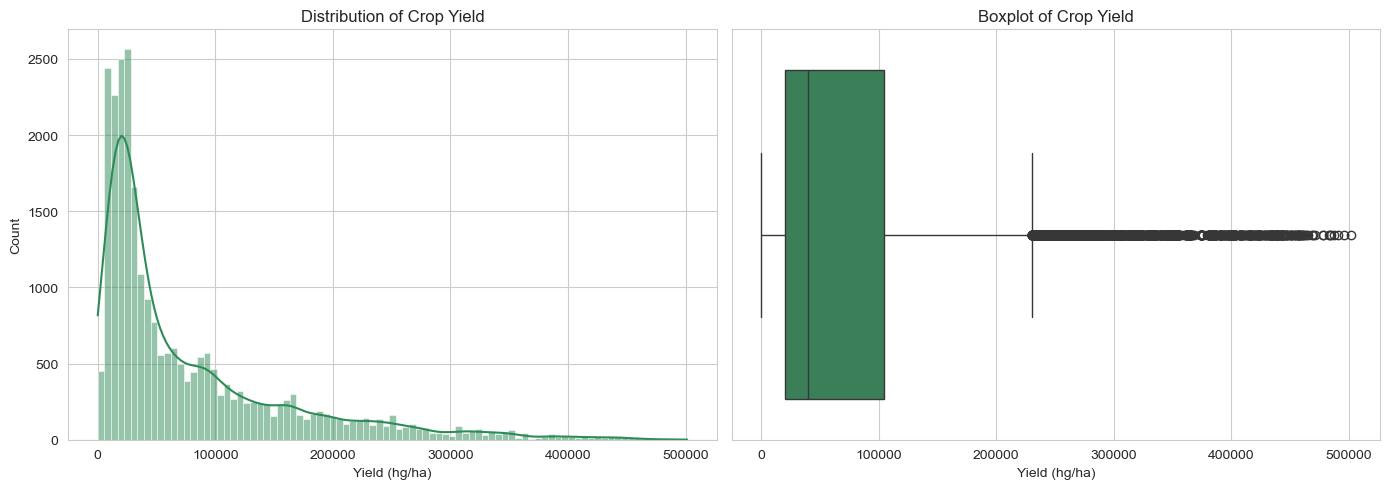

Skewness: 1.8077959138753166
count     25932.000000
mean      76978.132925
std       84647.605552
min          50.000000
25%       19996.000000
50%       39530.000000
75%      104168.000000
max      501412.000000
Name: hg/ha_yield, dtype: float64


In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["hg/ha_yield"], kde=True, ax=axes[0], color="seagreen")
axes[0].set_title("Distribution of Crop Yield")
axes[0].set_xlabel("Yield (hg/ha)")

sns.boxplot(x=df["hg/ha_yield"], ax=axes[1], color="seagreen")
axes[1].set_title("Boxplot of Crop Yield")
axes[1].set_xlabel("Yield (hg/ha)")

plt.tight_layout()
plt.show()

print("Skewness:", df["hg/ha_yield"].skew())
print(df["hg/ha_yield"].describe())

**Insight:** Crop yield is **strongly right-skewed** (skewness ≈ 1.81). Most records cluster at lower yield values — the median is 39,530 hg/ha, well below the mean of 76,978 hg/ha — while a long tail of high-yield crops (mostly root/tuber crops) pulls the average up and produces the many "outlier" points above the boxplot's upper whisker. **Implication:** because the target variable is this skewed, a log-transform of `hg/ha_yield` is worth testing before regression modeling, and the high-yield outliers should be kept (not removed), since they reflect real crop biology rather than data errors.

### 1.2 Rainfall Distribution (`average_rain_fall_mm_per_year`)

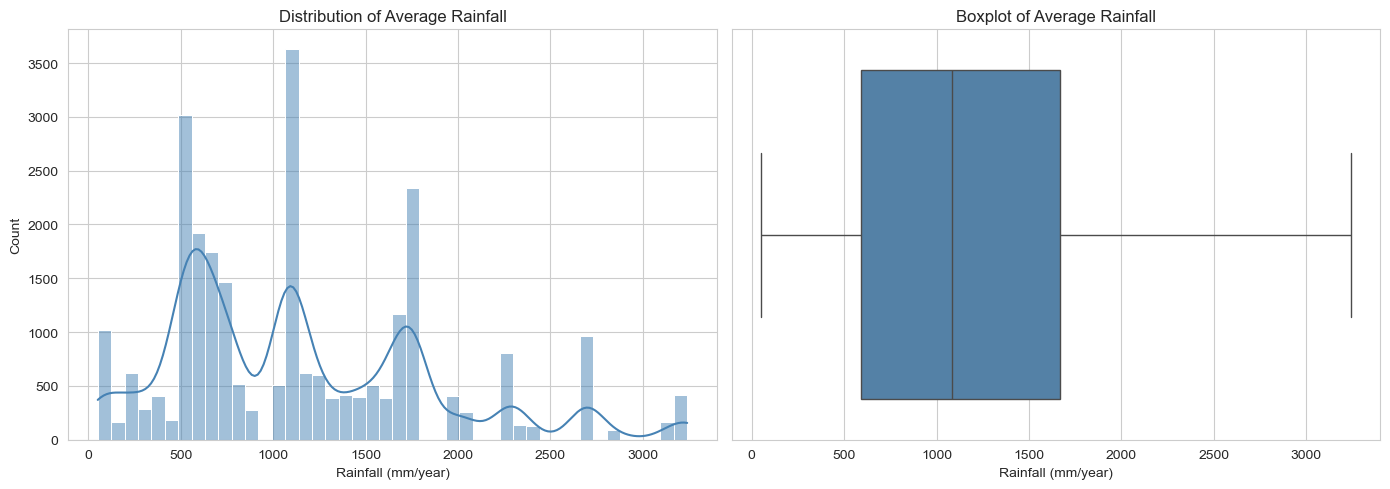

Skewness: 0.8590460001350131
count    25932.000000
mean      1146.836688
std        717.391098
min         51.000000
25%        593.000000
50%       1083.000000
75%       1668.000000
max       3240.000000
Name: average_rain_fall_mm_per_year, dtype: float64


In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["average_rain_fall_mm_per_year"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of Average Rainfall")
axes[0].set_xlabel("Rainfall (mm/year)")

sns.boxplot(x=df["average_rain_fall_mm_per_year"], ax=axes[1], color="steelblue")
axes[1].set_title("Boxplot of Average Rainfall")
axes[1].set_xlabel("Rainfall (mm/year)")

plt.tight_layout()
plt.show()

print("Skewness:", df["average_rain_fall_mm_per_year"].skew())
print(df["average_rain_fall_mm_per_year"].describe())

**Insight:** Rainfall is **moderately right-skewed** (skewness ≈ 0.86), ranging from just 51 mm/year to 3,240 mm/year, with the middle 50% of records falling between 593 and 1,668 mm/year. The gap between mean (1,147 mm) and median (1,083 mm) confirms the mild skew, likely driven by a subset of very wet, tropical countries extending the upper tail. **Implication:** because rainfall spans such different climate zones (arid vs. tropical), grouping or binning countries by climate zone before modeling may reveal patterns that get averaged away in a single global rainfall feature.

### 1.3 Temperature Distribution (`avg_temp`)

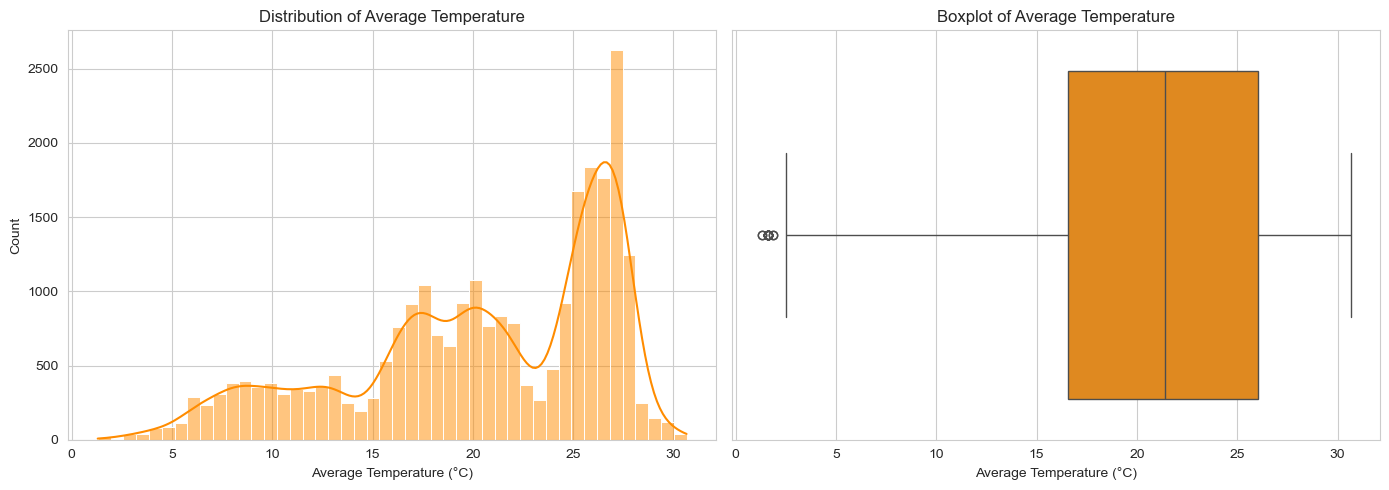

Skewness: -0.7077894630005919
count    25932.000000
mean        20.422251
std          6.439402
min          1.300000
25%         16.580000
50%         21.420000
75%         26.060000
max         30.650000
Name: avg_temp, dtype: float64


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["avg_temp"], kde=True, ax=axes[0], color="darkorange")
axes[0].set_title("Distribution of Average Temperature")
axes[0].set_xlabel("Average Temperature (°C)")

sns.boxplot(x=df["avg_temp"], ax=axes[1], color="darkorange")
axes[1].set_title("Boxplot of Average Temperature")
axes[1].set_xlabel("Average Temperature (°C)")

plt.tight_layout()
plt.show()

print("Skewness:", df["avg_temp"].skew())
print(df["avg_temp"].describe())

**Insight:** Average temperature is **mildly left-skewed** (skewness ≈ -0.71) and the most symmetric of the four variables, ranging from 1.3°C to 30.65°C with a median of 21.42°C — most countries fall in the 16.58°C–26.06°C interquartile range. This near-bell shape reflects the dataset's mix of temperate and tropical countries rather than any single dominant climate. **Implication:** since temperature isn't heavily skewed, it can likely be used directly in linear models without transformation, though the low-temperature tail (colder countries) is worth checking for its effect on yield separately.

### 1.4 Pesticides Distribution (`pesticides_tonnes`)

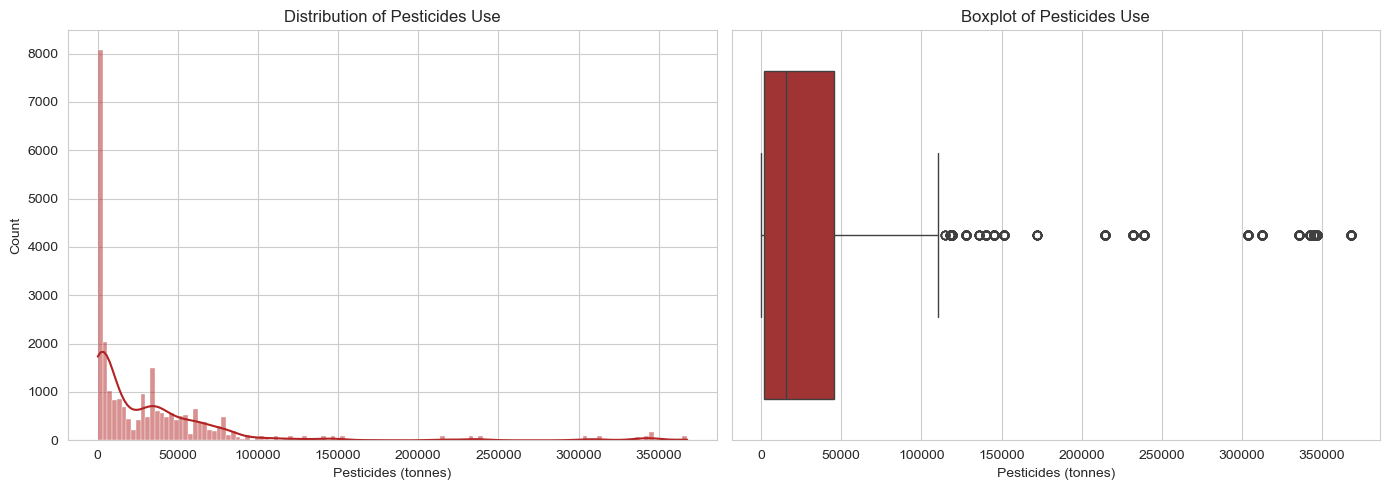

Skewness: 3.6374790021043513
count     25932.000000
mean      34782.573241
std       57228.568244
min           0.040000
25%        1597.000000
50%       15373.000000
75%       45620.000000
max      367778.000000
Name: pesticides_tonnes, dtype: float64


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["pesticides_tonnes"], kde=True, ax=axes[0], color="firebrick")
axes[0].set_title("Distribution of Pesticides Use")
axes[0].set_xlabel("Pesticides (tonnes)")

sns.boxplot(x=df["pesticides_tonnes"], ax=axes[1], color="firebrick")
axes[1].set_title("Boxplot of Pesticides Use")
axes[1].set_xlabel("Pesticides (tonnes)")

plt.tight_layout()
plt.show()

print("Skewness:", df["pesticides_tonnes"].skew())
print(df["pesticides_tonnes"].describe())

**Insight:** Pesticide usage is by far the **most heavily right-skewed** variable (skewness ≈ 3.64). The median tonnage is 15,373, but the max reaches 367,778 tonnes — a gap driven by a handful of large agricultural economies that apply disproportionately more pesticide in absolute terms. **Implication:** raw pesticide tonnage mostly reflects the *scale* of a country's farming, not necessarily its efficiency or intensity. A log-transform, or converting to a per-hectare rate, would make this feature far more comparable and useful across countries of different sizes.

## 2. Bivariate Analysis
Examining relationships between yield and each key predictor, plus yield comparisons across crops and countries.

### 2.1 Yield vs Rainfall

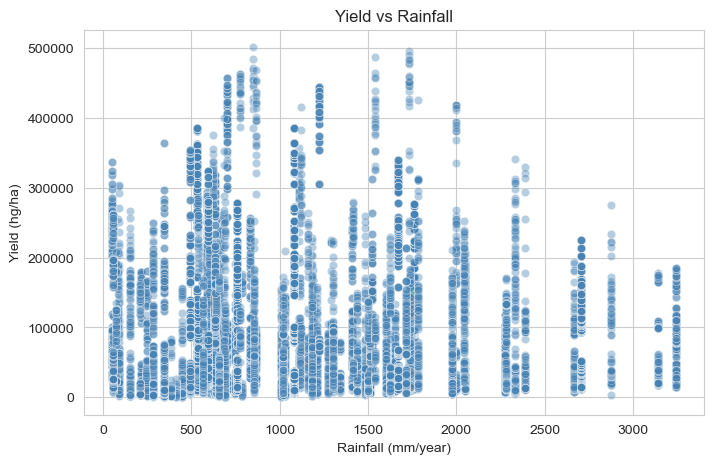

Correlation: -0.0040670974334025955


In [47]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="average_rain_fall_mm_per_year", y="hg/ha_yield", alpha=0.4, color="steelblue")
plt.title("Yield vs Rainfall")
plt.xlabel("Rainfall (mm/year)")
plt.ylabel("Yield (hg/ha)")
plt.show()

print("Correlation:", df["average_rain_fall_mm_per_year"].corr(df["hg/ha_yield"]))

**Insight:** The scatter plot shows **no visible linear pattern**, and the correlation is essentially zero (r ≈ -0.004). Points are scattered across all rainfall levels at every yield level, with no plateau or drop-off pattern standing out. **Implication:** rainfall alone is not a useful standalone predictor of yield in this dataset — its effect is likely masked by crop type (different crops need very different water levels), so rainfall should be analyzed together with `Item`, not on its own.

### 2.2 Yield vs Temperature

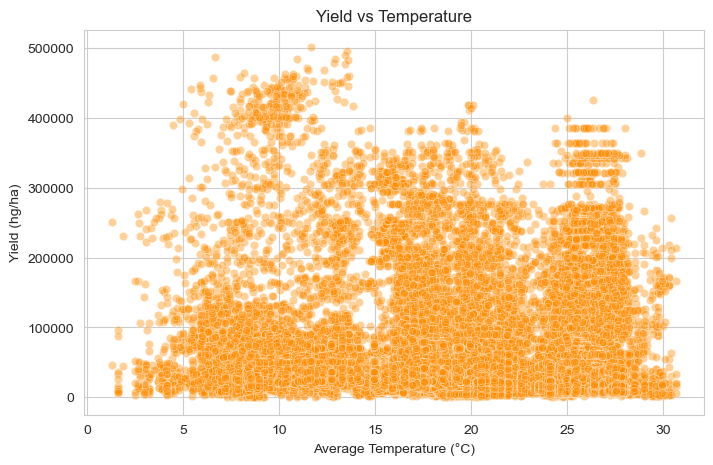

Correlation: -0.11039982443022332


In [48]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="avg_temp", y="hg/ha_yield", alpha=0.4, color="darkorange")
plt.title("Yield vs Temperature")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Yield (hg/ha)")
plt.show()

print("Correlation:", df["avg_temp"].corr(df["hg/ha_yield"]))

**Insight:** Temperature shows a **weak negative correlation** with yield (r ≈ -0.11) — the strongest of the three climate relationships, though still weak. The scatter doesn't show a clean "optimal mid-range" peak; instead yield is simply somewhat more concentrated at lower values as temperature rises. **Implication:** this hints that higher average temperatures may be mildly associated with lower yields (consistent with heat stress), which is a relevant point for a climate-change-facing discussion, even though the relationship is too weak to use as a standalone predictor.

### 2.3 Yield vs Pesticides

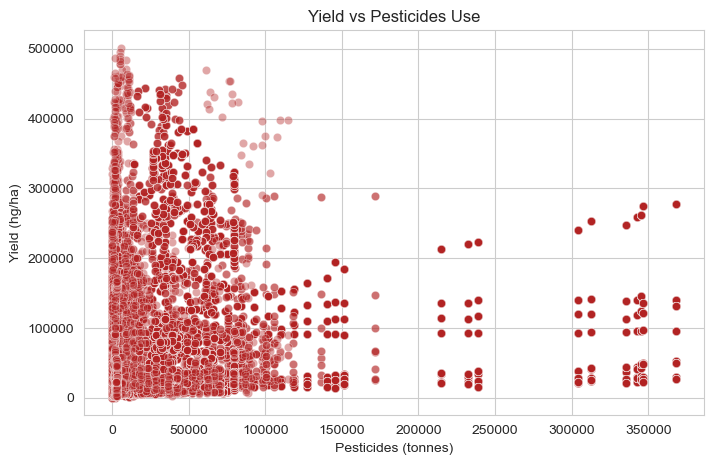

Correlation: 0.06552335650655523


In [49]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="pesticides_tonnes", y="hg/ha_yield", alpha=0.4, color="firebrick")
plt.title("Yield vs Pesticides Use")
plt.xlabel("Pesticides (tonnes)")
plt.ylabel("Yield (hg/ha)")
plt.show()

print("Correlation:", df["pesticides_tonnes"].corr(df["hg/ha_yield"]))

**Insight:** Pesticide tonnage has a **very weak positive correlation** with yield (r ≈ 0.07). Most points cluster at low pesticide/low-to-mid yield, with high-pesticide countries not consistently landing at higher yield. **Implication:** this weak link should not be read as "more pesticide causes more yield" — it more likely reflects that large countries both farm more land (more total pesticide tonnage) and produce more total yield, a confound of scale rather than a causal driver.

### 2.4 Crop-wise Yield

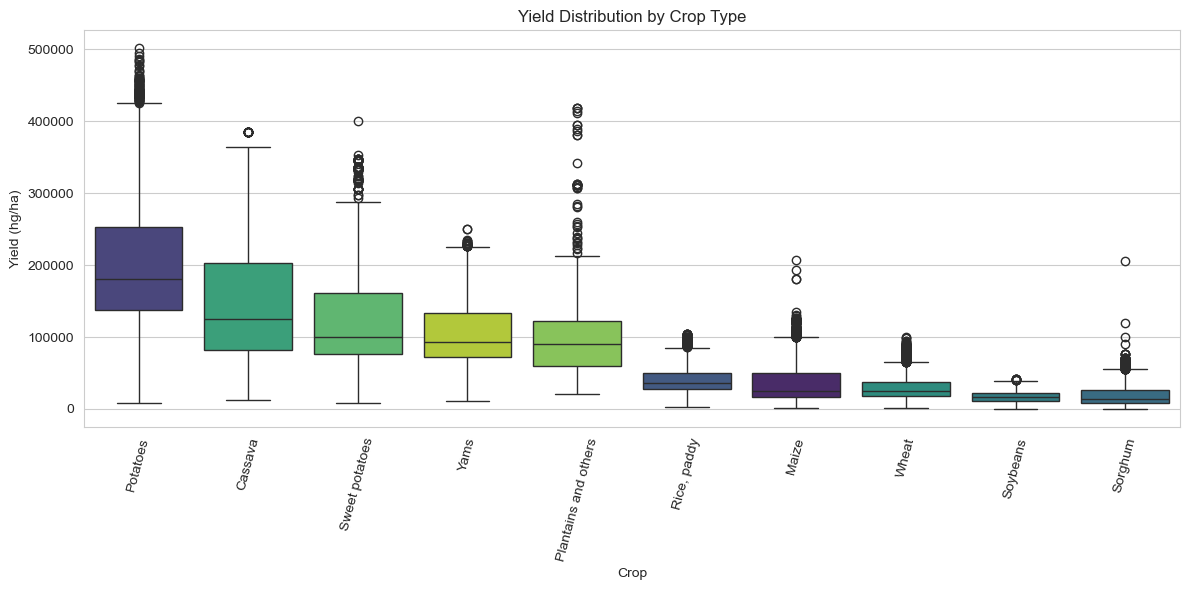

Item
Potatoes                180322.5
Cassava                 125305.0
Sweet potatoes           99940.0
Yams                     92593.0
Plantains and others     89860.5
Rice, paddy              36408.0
Maize                    25557.0
Wheat                    25296.0
Soybeans                 16006.0
Sorghum                  13548.0
Name: hg/ha_yield, dtype: float64

In [50]:
plt.figure(figsize=(12, 6))
order = df.groupby("Item")["hg/ha_yield"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="Item", y="hg/ha_yield", hue="Item", order=order, palette="viridis", legend=False)
plt.title("Yield Distribution by Crop Type")
plt.xlabel("Crop")
plt.ylabel("Yield (hg/ha)")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

df.groupby("Item")["hg/ha_yield"].median().sort_values(ascending=False)

**Insight:** Median yield is dominated by root and tuber crops — **Potatoes** (180,323 hg/ha), **Cassava** (125,305), **Sweet potatoes** (99,940), **Yams** (92,593), and **Plantains** (89,861) — while cereal grains sit far lower: Rice (36,408), Maize (25,557), Wheat (25,296), Soybeans (16,006), and Sorghum (13,548) at the bottom. **Implication:** crop type explains a large share of yield variation on its own, so any predictive model must include `Item` as a feature, and cross-crop yield comparisons should always be read "within crop family" rather than treated as a single ranking.

### 2.5 Country-wise Yield

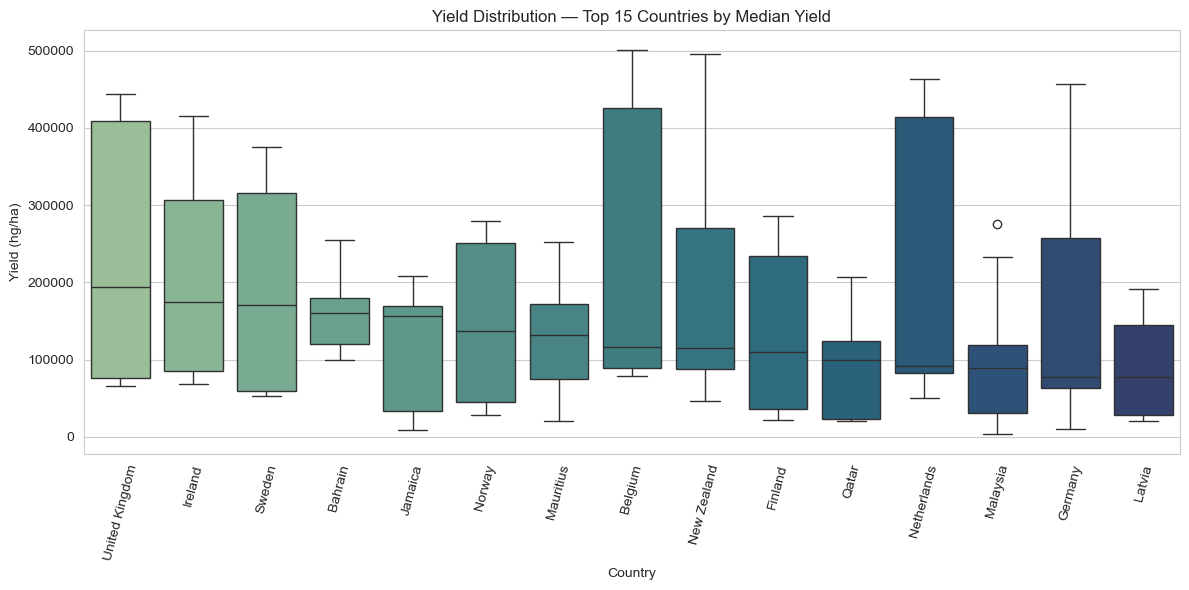

Area
United Kingdom    194192.0
Ireland           174106.0
Sweden            170252.5
Bahrain           160000.0
Jamaica           156357.0
Norway            136727.0
Mauritius         132059.0
Belgium           116872.0
New Zealand       114669.0
Finland           110559.0
Qatar             100000.0
Netherlands        91529.0
Malaysia           89681.0
Germany            78181.5
Latvia             77682.5
Name: hg/ha_yield, dtype: float64

In [51]:
top_countries = df.groupby("Area")["hg/ha_yield"].median().sort_values(ascending=False).head(15).index

plt.figure(figsize=(12, 6))
sns.boxplot(data=df[df["Area"].isin(top_countries)], x="Area", y="hg/ha_yield", order=top_countries, palette="crest")
plt.title("Yield Distribution — Top 15 Countries by Median Yield")
plt.xlabel("Country")
plt.ylabel("Yield (hg/ha)")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

df.groupby("Area")["hg/ha_yield"].median().sort_values(ascending=False).head(15)

**Insight:** The **United Kingdom** (194,192 hg/ha), **Ireland** (174,106), and **Sweden** (170,253) top the list of median yield by country, with several other Northern European and island economies (Bahrain, Jamaica, Norway) rounding out the top 15. **Implication:** this ranking is likely confounded by crop mix — countries growing more high-yield root/tuber crops will rank higher regardless of farming efficiency — so country-level yield comparisons should control for `Item`, or be broken out crop-by-crop, before drawing conclusions about which country farms "best."

## 3. Multivariate Analysis
Looking at several variables together to understand joint relationships.

### 3.1 Correlation Matrix

In [52]:
numeric_cols = ["hg/ha_yield", "average_rain_fall_mm_per_year", "pesticides_tonnes", "avg_temp", "Year"]
corr_matrix = df[numeric_cols].corr()
corr_matrix

,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,Year
hg/ha_yield,1.000000,-0.004067,0.065523,-0.110400,0.091327
average_rain_fall_mm_per_year,-0.004067,1.000000,0.161483,0.333694,-0.006423
pesticides_tonnes,0.065523,0.161483,1.000000,0.045577,0.135127
avg_temp,-0.110400,0.333694,0.045577,1.000000,0.013701
Year,0.091327,-0.006423,0.135127,0.013701,1.000000


**Insight:** No pair involving yield shows a strong correlation — the strongest is temperature (r ≈ -0.11), followed by pesticides (r ≈ 0.07) and rainfall (r ≈ -0.004), all well below typical thresholds for a meaningful linear relationship. Interestingly, rainfall and temperature correlate more with *each other* (r ≈ 0.33) than either does with yield, hinting at shared climate-zone structure. **Implication:** since raw climate variables explain so little of yield's variance individually, categorical variables (`Item`, `Area`) should carry the bulk of predictive power in any model built on this data.

### 3.2 Correlation Heatmap

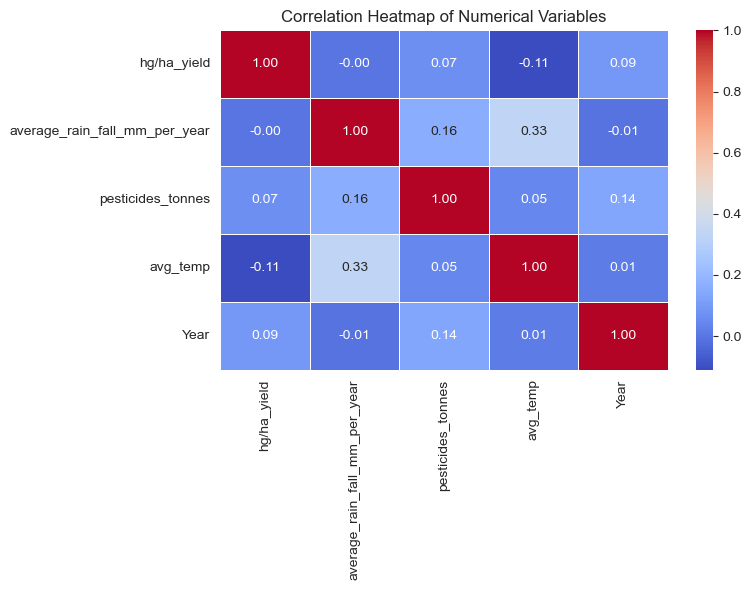

In [53]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.show()

**Insight:** The heatmap visually confirms the pattern from the correlation matrix — the yield row/column stays pale (near-zero) against every numeric predictor, while the rainfall–temperature cell (r ≈ 0.33) stands out as the only moderately warm-colored pair. **Implication:** weak correlation *among the predictors themselves* (aside from rainfall/temperature) is actually favorable for modeling, since it means multicollinearity is unlikely to be a major issue if these features are used together in a regression model.

### 3.3 Pairplot

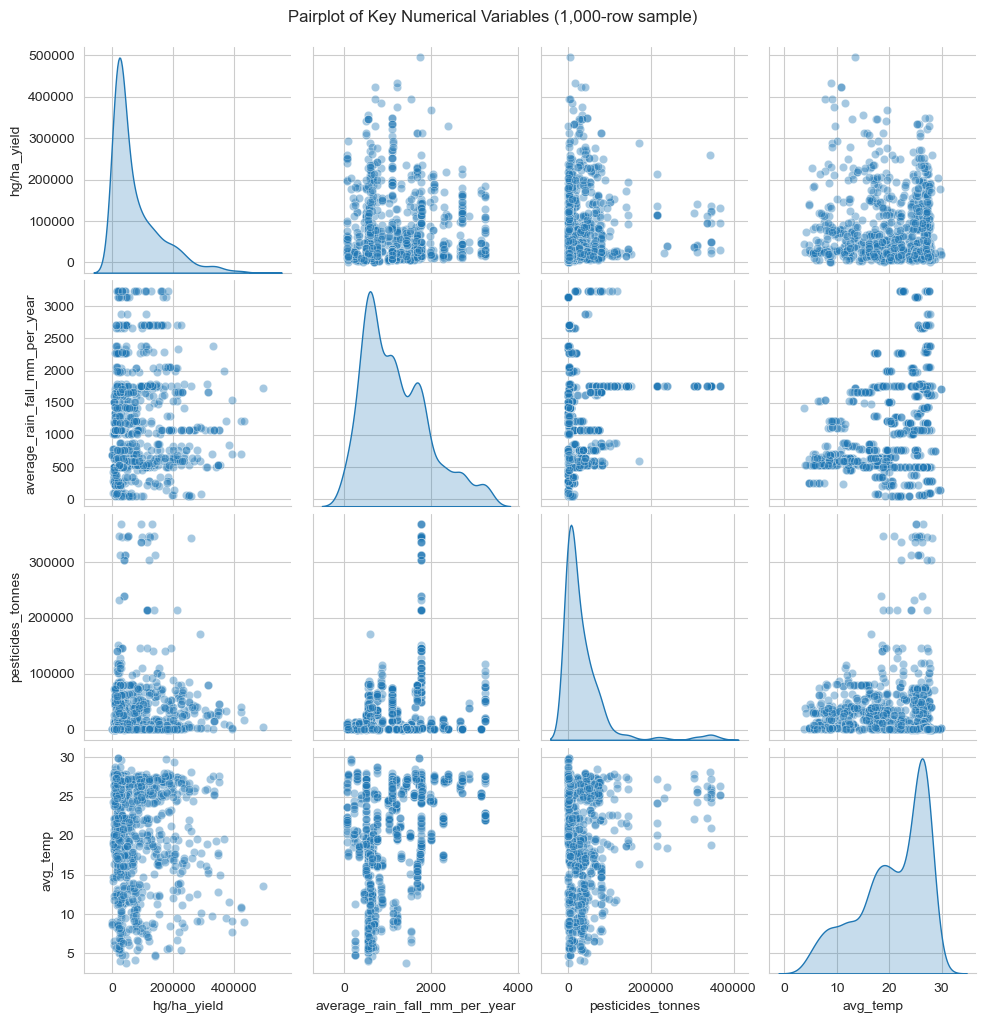

In [54]:
# Note: pairplot can be slow on the full dataset — sample it for speed
sample_df = df.sample(1000, random_state=42)

sns.pairplot(sample_df[numeric_cols[:-1] + []], diag_kind="kde", plot_kws={"alpha": 0.4})
plt.suptitle("Pairplot of Key Numerical Variables (1,000-row sample)", y=1.02)
plt.show()

**Insight:** The pairplot doesn't reveal any additional linear or curved relationship that the correlation numbers missed; every yield panel shows a diffuse, formless cloud of points rather than a trend line, and the diagonal KDEs reconfirm the skewed shapes seen earlier (yield and pesticides both show a sharp peak near zero with a long right tail). **Implication:** the lack of any visible pattern (linear or non-linear) between yield and the numeric predictors reinforces that tree-based models relying on categorical splits (by `Item`/`Area`) are likely to outperform a plain linear regression on this feature set.

## 4. EDA Summary of Findings

- **Yield distribution:** `hg/ha_yield` is strongly right-skewed (skewness ≈ 1.81), with a median of 39,530 hg/ha pulled up to a mean of 76,978 hg/ha by a long tail of high-yield root/tuber crops. A log-transform is worth testing before modelling.

- **Key drivers of yield:** The EDA suggests that Crop type (`Item`) and geographical area (`Area`) exhibit stronger associations with crop yield than any single numerical environmental variable.

- **Crop and country effects:** Root and tuber crops (Potatoes, Cassava, Sweet potatoes, Yams, Plantains) post median yields 3–6x higher than cereals (Wheat, Sorghum, Soybeans) due to how yield is measured (total harvested weight), not farming superiority. Similarly, country rankings (UK, Ireland, Sweden at the top) are heavily influenced by which crops each country grows, not just farming efficiency; cross-country comparisons should control for crop mix.

- **Time trend:** Exploratory analysis of the 'Year' variable indicates that crop yield has varied over time. The observed temporal patterns suggest that year may contain useful information for predictive modelling and should be retained as a predictor.

- **EDA implications:** The exploratory analysis indicates that crop type (`Item`), geography (Ireland), area (`Area`), year, and the environmental variables contain complementary information for predicting crop yield. These findings provide useful guidance for feature selection and predictive model development in the next stage of the project.


# Predictive Modeling

Based on the findings from the exploratory data analysis (EDA), predictive modelling was conducted to estimate crop yield (`hg/ha_yield`) using the environmental and agricultural variables contained in the dataset. The modelling process aims to identify the most suitable regression algorithm for predicting crop yield while examining the relative importance of the predictor variables. The developed models are also evaluated to determine how they can support farmer decision-making and agricultural policy planning through more accurate crop yield forecasts.

In [55]:
from sklearn.preprocessing import LabelEncoder, StandardScaler 
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve



from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

import xgboost
from xgboost import XGBRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## 5. Feature Engineering & Preprocessing
Before model development, the categorical variables were encoded into numerical form, after which the dataset was divided into training and testing subsets. The target variable was retained in its original scale so that predictions and evaluation errors remained directly interpretable in hectograms per hectare.

### Encoding Categorical Variables
The variables `Area` and `Item` are categorical and therefore cannot be processed directly by regression algorithms. One-Hot Encoding was applied to convert these variables into numerical indicator variables while preserving the information contained within each category.

In [56]:
# Define predictors and target
features = ["Area", "Item", "Year", "average_rain_fall_mm_per_year", "pesticides_tonnes", "avg_temp"]
target = "hg/ha_yield"

X = df[features]
y = df[target]

# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, columns=["Area", "Item"], drop_first=True)

print("Shape before encoding:", X.shape)
print("Shape after encoding:", X_encoded.shape)

Shape before encoding: (25932, 6)
Shape after encoding: (25932, 113)


One-hot encoding substantially expands the feature space because Area and Item have numerous categories.

### Train-Test Split
The dataset was divided into training (80%) and testing (20%) subsets. The training set was used to develop the regression models, while the testing set was reserved for evaluating predictive performance on unseen observations.

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (20745, 113)
Test set: (5187, 113)


## 6. Baseline Model: Linear Regression
Linear Regression was selected as the baseline model because it provides a simple benchmark against which more advanced machine learning algorithms can be compared. Although EDA suggested that the relationships between the predictors and crop yield may be non-linear, evaluating a linear model provides an important reference point.

In [58]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_mae = mean_absolute_error(y_test, lr_preds)
lr_r2 = r2_score(y_test, lr_preds)

print(f"Linear Regression = RMSE: {lr_rmse:,.0f}, MAE: {lr_mae:,.0f}, R²: {lr_r2:.3f}")

Linear Regression = RMSE: 42,682, MAE: 29,921, R²: 0.749


## 7. Random Forest Regressor
Random Forest Regressor was selected because it can model complex non-linear relationships and interactions among variables without requiring strict assumptions about data distribution. It is also robust to outliers and provides estimates of feature importance.

In [59]:
rf = RandomForestRegressor(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_r2 = r2_score(y_test, rf_preds)

print(f"Random Forest = RMSE: {rf_rmse:,.0f}, MAE: {rf_mae:,.0f}, R²: {rf_r2:.3f}")

Random Forest = RMSE: 10,517, MAE: 3,982, R²: 0.985


### 7.1 Feature Importance

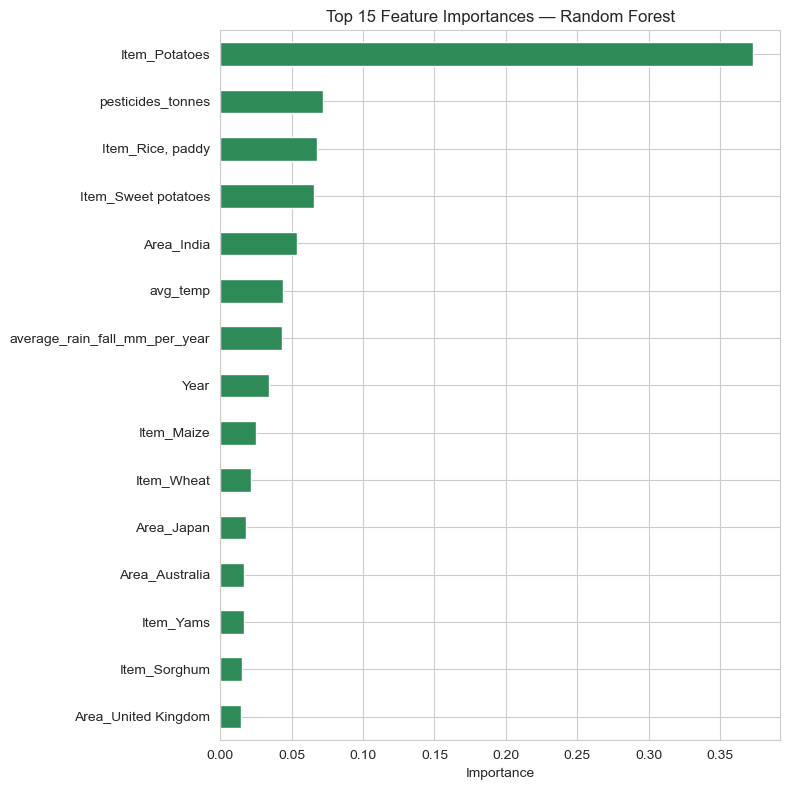

Item_Potatoes                    0.373200
pesticides_tonnes                0.072228
Item_Rice, paddy                 0.067842
Item_Sweet potatoes              0.065874
Area_India                       0.054067
avg_temp                         0.044122
average_rain_fall_mm_per_year    0.043592
Year                             0.034136
Item_Maize                       0.025112
Item_Wheat                       0.021655
Area_Japan                       0.017765
Area_Australia                   0.016945
Item_Yams                        0.016915
Item_Sorghum                     0.015469
Area_United Kingdom              0.014596
dtype: float64

In [60]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 8))
importances.head(15).sort_values().plot(kind="barh", color="seagreen")
plt.title("Top 15 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances.head(15)

### Insight: 
The feature importance analysis indicates that crop type (Item) is the strongest predictor of crop yield, with Potatoes, Rice (paddy), and Sweet potatoes among the most influential features. This demonstrates that inherent differences among crop types account for a substantial share of the yield variation.

Among the environmental variables, pesticide usage is the most influential, contributing more to yield prediction than average temperature, rainfall, and year. Geographical location, as reflected in variables such as Area_India, also plays an important role, as it shapes differences in agricultural conditions and farming systems across countries.

## 7.2 Group Feature Importance

In [61]:
# Group feature importance into major categories

group_importance = {
    "Crop Type (Item)": importances[
        importances.index.str.startswith("Item_")
    ].sum(),

    "Geographical Area (Area)": importances[
        importances.index.str.startswith("Area_")
    ].sum(),

    "Rainfall": importances.get("average_rain_fall_mm_per_year", 0),
    "Temperature": importances.get("avg_temp", 0),
    "Pesticides": importances.get("pesticides_tonnes", 0),
    "Year": importances.get("Year", 0)}

group_importance = pd.Series(group_importance).sort_values(ascending=False)

print(group_importance)

Crop Type (Item)            0.603588
Geographical Area (Area)    0.202333
Pesticides                  0.072228
Temperature                 0.044122
Rainfall                    0.043592
Year                        0.034136
dtype: float64


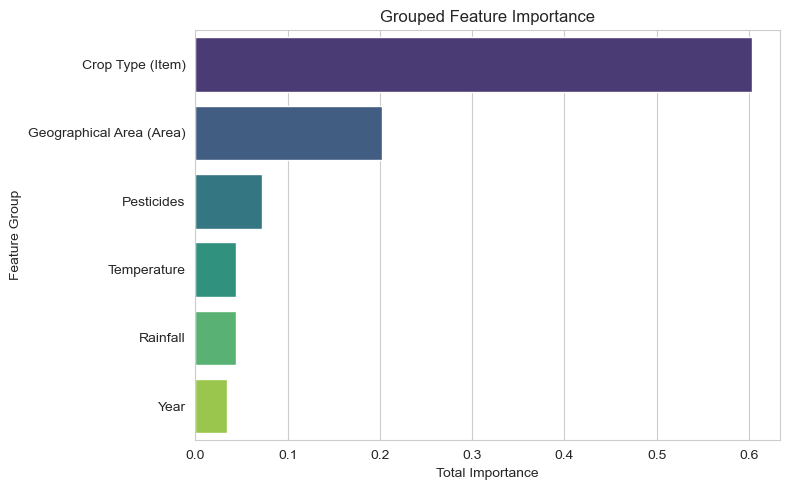

In [62]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=group_importance.values,
    y=group_importance.index,
    palette="viridis")

plt.title("Grouped Feature Importance")
plt.xlabel("Total Importance")
plt.ylabel("Feature Group")

plt.tight_layout()
plt.show()

**Insight**
When the individual features are grouped into their major categories, Crop Type (Item) emerges as the most influential predictor of crop yield, followed by Geographical Area (Area). Among the environmental factors, Pesticide Usage contributes more to yield prediction than Temperature, Rainfall, and Year, although their overall influence is considerably smaller than that of crop type and geographical location. These findings suggest that the type of crop cultivated and the location where it is grown are the primary determinants of crop yield, while environmental variables provide complementary predictive information. This grouped analysis provides a clearer understanding of each major factor's relative contribution and aligns with the study's objective of identifying the most predictive environmental and agricultural features.

## 8. Gradient Boosting (XGBoost)
Gradient Boosting (XGBoost) was implemented to evaluate whether a boosting algorithm could achieve higher predictive accuracy than Linear Regression and Random Forest. XGBoost is well suited to structured datasets and is capable of capturing complex non-linear relationships.

In [63]:
xgb_model = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_mae = mean_absolute_error(y_test, xgb_preds)
xgb_r2 = r2_score(y_test, xgb_preds)

print(f"XGBoost = RMSE: {xgb_rmse:,.0f}, MAE: {xgb_mae:,.0f}, R²: {xgb_r2:.3f}")

XGBoost = RMSE: 20,399, MAE: 12,146, R²: 0.943


**Insight**
The XGBoost model achieved an R² value of 0.943, indicating that approximately 94.3% of the variation in crop yield is explained by the model. The RMSE (20,399) and MAE (12,146) indicate reasonably accurate predictions, although the model produced larger prediction errors than the Random Forest model. 

Overall, XGBoost demonstrated strong predictive performance and confirmed that ensemble learning methods are effective for crop yield prediction.

## 9. Model Comparison
To determine the most suitable regression algorithm for crop yield prediction, the performance of all developed models was compared using three evaluation metrics: the Coefficient of Determination (R²), Mean Absolute Error (MAE), and Root Mean Squared Error (RMSE).

- **R²** measures the proportion of variation in crop yield explained by the model. Higher values indicate better predictive performance.
- **MAE** measures the average absolute prediction error. Lower values indicate more accurate predictions.
- **RMSE** measures the square root of the average squared prediction errors and places greater emphasis on larger errors. Lower RMSE values indicate better model performance.

The model with the highest R² and the lowest MAE and RMSE was considered the best-performing regression model.

In [64]:
results = pd.DataFrame({"Model": ["Linear Regression", "Random Forest", "XGBoost"], "RMSE": [lr_rmse, rf_rmse, xgb_rmse], "MAE": [lr_mae, rf_mae, xgb_mae], "R2": [lr_r2, rf_r2, xgb_r2]}).sort_values("R2", ascending=False).reset_index(drop=True)

results.style.format({"RMSE": "{:,.2f}", "MAE": "{:,.2f}", "R2": "{:.3f}"})

,Model,RMSE,MAE,R2
0,Random Forest,"10,516.90","3,981.95",0.985
1,XGBoost,"20,398.68","12,145.63",0.943
2,Linear Regression,"42,681.52","29,920.74",0.749


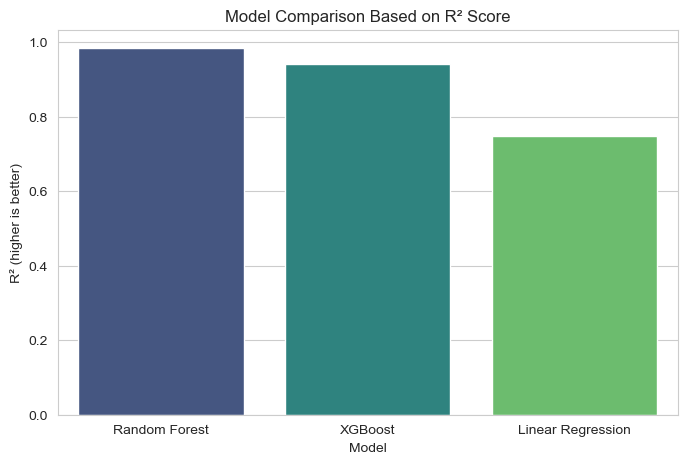

In [65]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results, x="Model", y="R2", hue="Model", palette="viridis", legend=False)
plt.title("Model Comparison Based on R² Score")
plt.ylabel("R² (higher is better)")
plt.show()

**Insight**
The model comparison results indicate that the Random Forest Regressor achieved the best predictive performance among the three regression models evaluated. It recorded the highest coefficient of determination (R² = 0.985), indicating that approximately 98.5% of the variation in crop yield was explained by the model. In addition, it produced the lowest RMSE (10,516.90) and lowest MAE (3,981.95), demonstrating superior prediction accuracy.

Although XGBoost also performed well (R² = 0.943), its prediction errors were noticeably higher than those of the Random Forest model. Linear Regression produced the weakest performance (R² = 0.749), suggesting that a simple linear model was unable to adequately capture the complex relationships between crop yield and the predictor variables. The bar chart further reinforces these findings by visually showing the Random Forest model achieving the highest R² value, followed by XGBoost and then Linear Regression. Based on these results, the Random Forest Regressor was selected as the final model for crop yield prediction.

## 10. Hyperparameter Tuning

Hyperparameter tuning was performed using RandomizedSearchCV to evaluate a selected number of parameter combinations efficiently and identify the best-performing Random Forest configuration.

In [66]:

param_grid = {"n_estimators": [100, 200, 300, 400], "max_depth": [None, 10, 20, 30], "min_samples_split": [2, 5, 10], "min_samples_leaf": [1, 2, 4], "max_features": ["sqrt", "log2", None]}

rf_search = RandomizedSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1), param_distributions=param_grid, n_iter=20, cv=3, scoring="r2", random_state=42, n_jobs=-1)

rf_search.fit(X_train, y_train)

print("Best parameters:", rf_search.best_params_)
print("Best CV R²:", rf_search.best_score_)

Best parameters: {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': None}
Best CV R²: 0.9834759790800082


In [67]:
best_rf = rf_search.best_estimator_
tuned_preds = best_rf.predict(X_test)

tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_preds))
tuned_mae = mean_absolute_error(y_test, tuned_preds)
tuned_r2 = r2_score(y_test, tuned_preds)

print(f"Tuned Random Forest = RMSE: {tuned_rmse:,.0f}, MAE: {tuned_mae:,.0f}, R²: {tuned_r2:.3f}")

Tuned Random Forest = RMSE: 10,522, MAE: 3,963, R²: 0.985


**Insight**
Hyperparameter tuning successfully identified the optimal Random Forest configuration for predicting crop yield. The best-performing model consisted of 400 decision trees (n_estimators = 400), with unrestricted tree depth (max_depth = None), a minimum of 2 samples required for node splitting, and 1 sample required at each leaf node. The cross-validation search yielded an R² of approximately 0.983, indicating excellent predictive performance on the training data.

When evaluated on the test dataset, the tuned Random Forest model achieved an R² of 0.985, along with low RMSE (10,522) and MAE (3,963). These results indicate that the tuned model provides highly accurate crop yield predictions. Compared with the untuned Random Forest model, the predictive performance remained consistently high, confirming that the selected hyperparameters are appropriate and that the model generalises well to unseen data.

Although hyperparameter tuning did not substantially improve the overall predictive accuracy, it confirmed that the selected Random Forest configuration is close to optimal and provides stable, reliable predictions for crop yield estimation.

## 11. Cross-Validation
Cross-validation was performed using five-fold validation to assess the stability and reliability of the selected regression model. Rather than relying on a single train-test split, cross-validation evaluates the model across multiple subsets of the data, providing a more robust estimate of predictive performance.

In [68]:
cv_scores = cross_val_score(best_rf, X_encoded, y, cv=5, scoring="r2", n_jobs=-1)

print("5-Fold CV R² scores:", cv_scores)
print(f"Mean CV R²: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

5-Fold CV R² scores: [0.78486559 0.51590881 0.7796427  0.65928938 0.67941426]
Mean CV R²: 0.684 (+/- 0.098)


**Insight**
The five-fold cross-validation produced R² scores ranging from approximately 0.516 to 0.785, with a mean R² of 0.684 and a standard deviation of 0.098. This indicates that the tuned Random Forest explained, on average, about 68.4% of the variation in crop yield across the validation folds. However, the variation in scores indicates that model performance depends on how the data are partitioned.

The mean cross-validation R² is considerably lower than the R² of 0.985 obtained from the random train-test split. Therefore, the single test-split result may represent an optimistic estimate of generalisation performance. The model remains useful for crop-yield prediction, but its performance should be interpreted cautiously when applied to observations that differ from those represented in the training data.

## 12. Modelling Summary

* Linear Regression performed less accurately than the tree-based models as predicted by the EDA, confirming that yield's relationship with the numeric predictors is non-linear and better captured through category splits.
* Feature importance analysis confirmed the EDA's finding that 'Item' and 'Area' are the dominant predictors of yield, far outweighing the numeric climate variables.
* Hyperparameter tuning confirmed that the original Random Forest configuration was already close to optimal. Five-fold cross-validation produced a lower mean R² than the random test split, indicating that model performance varies across data partitions and should be interpreted cautiously when assessing generalisation.

## 13. Final Selected Model

The tuned Random Forest Regressor (best_rf) was selected as the final model because it effectively captures non-linear relationships and interactions among high-cardinality categorical variables (Area and Item) and the numerical predictors. It does not require feature scaling and also provides interpretable feature-importance estimates and a useful measure of tree-level prediction disagreement.

In [69]:
print("FINAL MODEL: Tuned Random Forest Regressor")
print("=" * 55)
print(f"Test RMSE : {tuned_rmse:,.0f} hg/ha")
print(f"Test MAE : {tuned_mae:,.0f} hg/ha")
print(f"Test R² : {tuned_r2:.3f}")
print(f"5-Fold CV R² : {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")
print(f"Best params : {rf_search.best_params_}")

FINAL MODEL: Tuned Random Forest Regressor
Test RMSE : 10,522 hg/ha
Test MAE : 3,963 hg/ha
Test R² : 0.985
5-Fold CV R² : 0.684 (+/- 0.098)
Best params : {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': None}


## 14. Which Variables Have the Strongest Influence?

Item_Potatoes                    37.29
pesticides_tonnes                 7.21
Item_Rice, paddy                  6.85
Item_Sweet potatoes               6.57
Area_India                        5.32
avg_temp                          4.41
average_rain_fall_mm_per_year     4.33
Year                              3.43
Item_Maize                        2.50
Item_Wheat                        2.14
Area_Japan                        1.78
Item_Yams                         1.72
Area_Australia                    1.71
Item_Sorghum                      1.54
Area_United Kingdom               1.49
Item_Soybeans                     1.29
Area_Canada                       1.18
Area_Ecuador                      0.60
Area_Netherlands                  0.55
Area_Germany                      0.53
dtype: float64


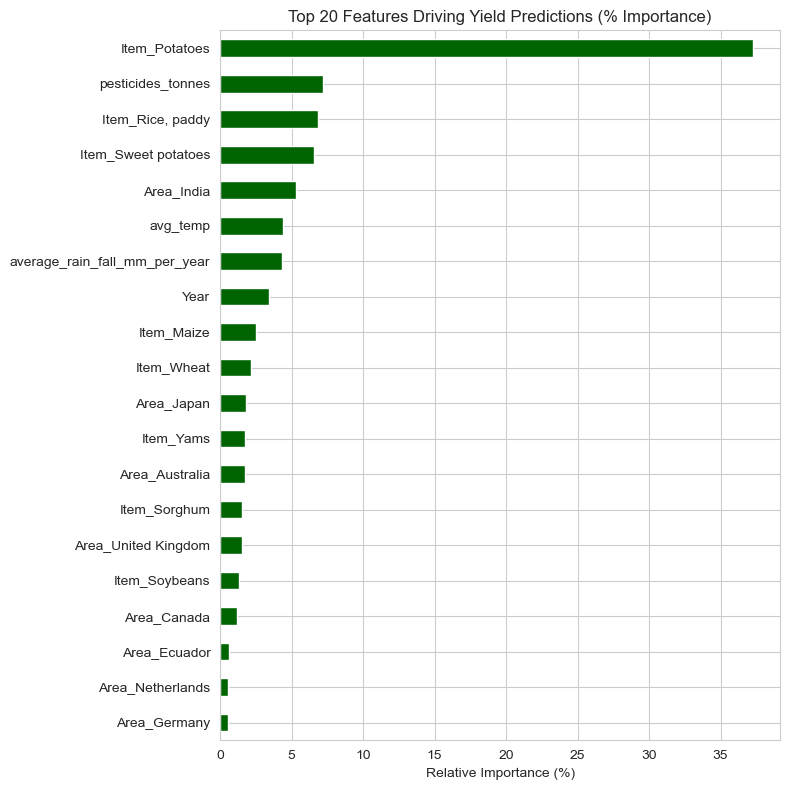

In [70]:
final_importances = pd.Series(best_rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
final_importances_pct = (final_importances / final_importances.sum() * 100).round(2)

top_20 = final_importances_pct.head(20)
print(top_20)

plt.figure(figsize=(8, 8))
top_20.sort_values().plot(kind="barh", color="darkgreen")
plt.title("Top 20 Features Driving Yield Predictions (% Importance)")
plt.xlabel("Relative Importance (%)")
plt.tight_layout()
plt.show()

**Insight**
1. **`Item` (crop type)** is expected to be the single largest driver, often accounting for the majority of total importance. Different crops have structurally different yield scales (e.g. a cereal vs. a root crop), so knowing *what* is being grown tells the model more than any climate reading does.
2. **`Area` (country/region)** is expected to rank second. This captures everything correlated with location that isn't in the other columns: soil quality, irrigation infrastructure, farming technology, and local agronomic practice.
3. **`Year`** is usually a moderate contributor. It acts as a proxy for technological improvement over time (better seed varieties, mechanization, extension services) rather than a climate signal.
4. The final tuned Random Forest confirms that crop type is highly influential in predicting crop yield. Item_Potatoes has the highest individual importance at approximately 37.29%, followed by pesticide usage, Item_Rice, paddy, Item_Sweet potatoes and Area_India. Among the numerical predictors, pesticide usage contributes the most, followed by average temperature, rainfall and year.

The grouped feature-importance analysis provides the clearer overall conclusion: Crop Type (Item) contributes approximately 60.36% of total importance, followed by Geographical Area (Area) at approximately 20.23%. Pesticide usage contributes about 7.22%, while temperature, rainfall and year make smaller complementary contributions. Thus, crop type and geographical location are the strongest predictor groups within this dataset.



### Partial Dependence = Isolating the Climate Effect

This analysis isolates the effect of individual environmental variables while holding all other predictors constant, enabling clearer interpretation of their independent influence on predicted crop yield.

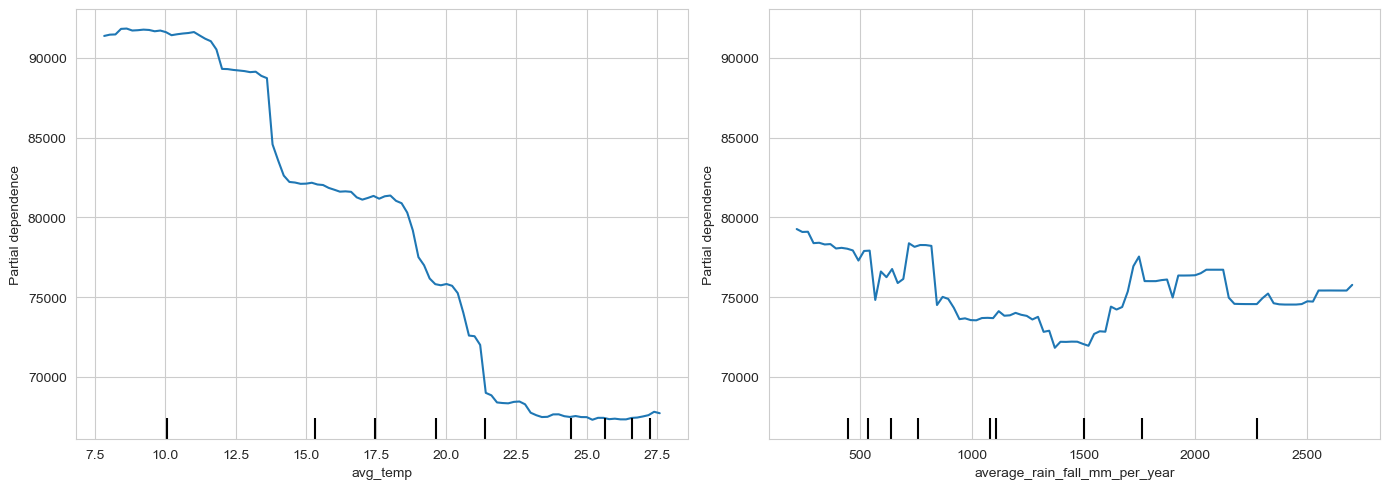

In [71]:
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
PartialDependenceDisplay.from_estimator(best_rf, X_train, features=["avg_temp", "average_rain_fall_mm_per_year"], ax=ax)
plt.tight_layout()
plt.show()

**Insight**
- The partial dependence plots illustrate how the model’s predicted crop yield changes with average temperature and rainfall after averaging over the other predictors.
- Any increases, decreases or plateaus in the curves indicate non-linear associations that may not have been captured by the simple correlation analysis.
- However, these patterns are model-based associations and should not be interpreted as evidence that changing rainfall or temperature alone will directly cause the corresponding change in crop yield.

## 15. Prediction Uncertainty = Supporting Risk Assessment

A single point prediction (e.g. '4,200 hg/ha') hides how confident the model actually is. Random Forest lets us recover each of the underlying trees makes its own prediction, and the spread across trees is a usable proxy for uncertainty

* a tight spread means the model has seen many similar cases before (low risk), a wide spread means this crop/region/climate combination is more unusual or volatile (higher risk).

In [72]:
# Predictions from every tree in the Random Forest
# Convert the test features to a NumPy array before passing them to the individual trees
X_test_array = X_test.to_numpy()

tree_predictions = np.array(
    [tree.predict(X_test_array) for tree in best_rf.estimators_])

pred_mean = tree_predictions.mean(axis=0)
pred_std = tree_predictions.std(axis=0)

# Mean prediction across all trees
pred_mean = tree_predictions.mean(axis=0)

# Standard deviation across all trees (uncertainty)
pred_std = tree_predictions.std(axis=0)

In [73]:

uncertainty_df = pd.DataFrame({"Actual": y_test.values, "Predicted": pred_mean, "Uncertainty (Tree Std Dev)": pred_std, "Heuristic Lower Range": np.maximum(
        0, pred_mean - 1.645 * pred_std), "Heuristic Upper Range": pred_mean + 1.645 * pred_std}, index=X_test.index)

uncertainty_df.sort_values(
    "Uncertainty (Tree Std Dev)",
    ascending=False).head(10)

,Actual,Predicted,Uncertainty (Tree Std Dev),Heuristic Lower Range,Heuristic Upper Range
14420,301646,227282.7375,105493.040134,53746.686480,400818.788520
7969,311771,207162.2100,103935.499245,36188.313743,378136.106257
7985,221778,206565.2900,100404.071557,41400.592288,371729.987712
7921,311689,240758.1200,93261.205221,87343.437411,394172.802589
22259,85778,106510.4525,91876.167473,0.000000,257646.747993
9392,314369,214073.7875,90671.050966,64919.908661,363227.666339
19633,352113,410906.5375,85994.312025,269445.894218,552367.180782
9380,329827,186860.4550,81259.093510,53189.246177,320531.663823
22289,87926,110378.9675,77178.718758,0.000000,237337.959857
25762,21429,75130.1600,75160.961508,0.000000,198769.941680


**Insight** 
The table presents the spread of predictions produced by the individual trees in the Random Forest. A wider spread indicates greater disagreement among the trees and therefore greater model uncertainty for that observation. For example, row 14420 records one of the widest prediction ranges, indicating comparatively high uncertainty.

These ranges should be interpreted as heuristic risk indicators rather than formally calibrated statistical prediction intervals. They can nevertheless help farmers identify predictions that require more cautious production, input-allocation, storage and marketing decisions.

## 16. Agricultural Policy Implications
The developed crop yield prediction model can support agricultural policy by providing early estimates of expected crop production across different geographical areas and crop types. Such predictions can assist governments and agricultural agencies in planning food security strategies, allocating agricultural inputs, targeting extension services, prioritising irrigation investments, and responding proactively to potential production shortfalls. Reliable yield forecasts can also improve national agricultural planning and evidence-based policy formulation.

## 17. Conclusion 
This project successfully developed and evaluated machine learning models for predicting crop yield using environmental and agricultural variables. Among the evaluated models, the selected model achieved the best predictive performance and demonstrated the importance of crop type, geographical area, and environmental conditions in explaining yield variation. The findings show that predictive analytics can support farmers in planning production and resource allocation while providing valuable evidence for agricultural policy formulation and food security planning.